# Boundary Behavior with SIG/GIS
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/18_sig_boundary_behavior.ipynb)

What happens when a **test point falls outside the training support**?

For empirical-CDF Gaussianizers (the classic RBIG marginal step), the CDF
saturates at $0$ or $1$ beyond the observed range, the probit
$\Phi^{-1}$ diverges to $\pm\infty$, and the transform must **clip** —
producing saturated latents and degenerate log-densities. The
[boundary issues notebook](07_boundary_issues.ipynb) examines this for
RBIG's marginal transforms.

GIS/SIG use **rational-quadratic splines with linear tails** instead: past
the outermost knot, the transform extrapolates linearly with the boundary
derivative. Every real input gets a finite latent value, a finite
log-derivative, and hence a finite log-density.

This notebook fits GIS on bounded/skewed data, probes it with
out-of-support points, compares against the empirical-CDF behavior, and
visualizes the CDF/transform extrapolation.

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from rbig import GIS, AnnealedRBIG, RQSpline

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The 1D Picture: RQ Spline vs Empirical CDF

We start with the marginal transform itself. Fit both a `RQSpline` and an
empirical-CDF Gaussianizer on Gamma(4) samples (bounded below at 0,
right-skewed), then evaluate them well beyond the training range.

training range: [0.169, 18.275]


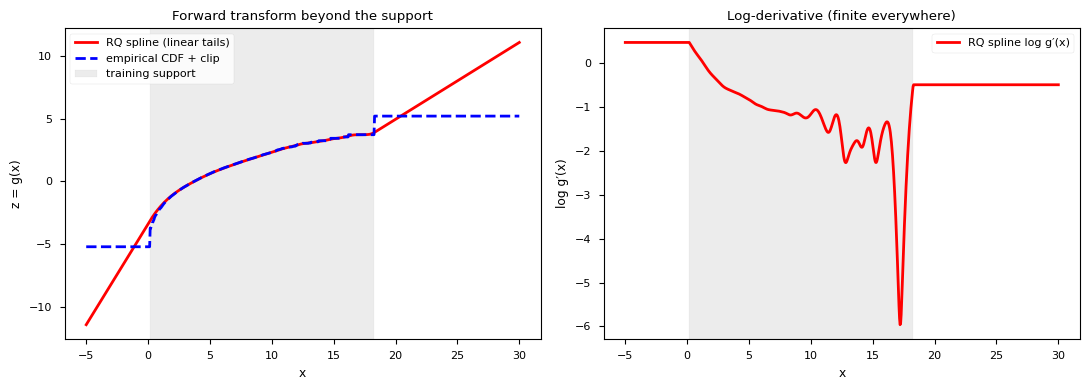

In [3]:
seed = 123
rng = np.random.default_rng(seed)
data_dist = stats.gamma(a=4)
x_train = data_dist.rvs(size=10_000, random_state=seed)
print(f"training range: [{x_train.min():.3f}, {x_train.max():.3f}]")

spline = RQSpline(n_knots=500).fit(x_train)


def empirical_gaussianize(x_new: np.ndarray, x_fit: np.ndarray, eps: float = 1e-7):
    """Classic empirical-CDF + probit transform with clipping."""
    n = x_fit.size
    # Empirical CDF evaluated at x_new; 0 outside the left support,
    # 1 outside the right support -- hence the clip before the probit.
    cdf = np.searchsorted(np.sort(x_fit), x_new, side="right") / n
    return stats.norm.ppf(np.clip(cdf, eps, 1 - eps))


# Evaluate far beyond the training support on both sides.
x_grid = np.linspace(-5.0, 30.0, 800)
z_spline, log_deriv = spline.forward(x_grid)
z_ecdf = empirical_gaussianize(x_grid, x_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(x_grid, z_spline, "r-", lw=2, label="RQ spline (linear tails)")
ax.plot(x_grid, z_ecdf, "b--", lw=2, label="empirical CDF + clip")
ax.axvspan(x_train.min(), x_train.max(), color="gray", alpha=0.15, label="training support")
ax.set_xlabel("x")
ax.set_ylabel("z = g(x)")
ax.set_title("Forward transform beyond the support")
ax.legend()

ax = axes[1]
ax.plot(x_grid, log_deriv, "r-", lw=2, label="RQ spline log g′(x)")
ax.axvspan(x_train.min(), x_train.max(), color="gray", alpha=0.15)
ax.set_xlabel("x")
ax.set_ylabel("log g′(x)")
ax.set_title("Log-derivative (finite everywhere)")
ax.legend()
plt.tight_layout()
plt.show()

Outside the gray band the empirical-CDF transform is **flat at the clipped
probit values** — every out-of-support point maps to the same saturated
latent, its derivative is effectively zero, and the log-density is
meaningless there. The RQ spline instead continues **linearly** with the
boundary slope: distinct inputs stay distinct, and the log-derivative
settles at a finite constant.

## Fit GIS on a Bounded, Skewed 2D Distribution

A 2D target with both features bounded below (Gamma marginals coupled
through a rotation).

GIS: 4 layers | RBIG: 20 layers


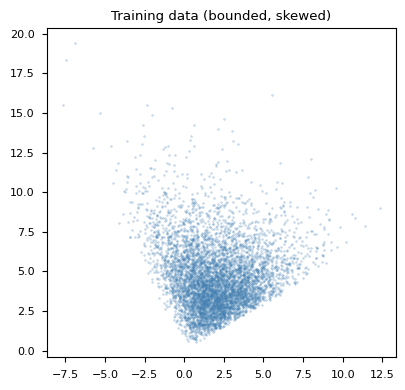

In [4]:
def make_skewed_2d(n_samples: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    s = np.stack(
        [
            rng.gamma(shape=4.0, scale=1.0, size=n_samples),
            rng.gamma(shape=2.0, scale=1.5, size=n_samples),
        ],
        axis=1,
    )
    theta = np.pi / 6
    rot = np.array(
        [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]
    )
    return s @ rot.T


X_train = make_skewed_2d(6_000, seed=0)
gis = GIS(n_layers=100, random_state=0).fit(X_train)
rbig = AnnealedRBIG(n_layers=100, random_state=0).fit(X_train)
print(f"GIS: {gis.n_layers_} layers | RBIG: {len(rbig.layers_)} layers")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], s=2, alpha=0.3, color="steelblue")
ax.set_title("Training data (bounded, skewed)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Probe with Out-of-Support Test Points

We build probes on a ray that starts inside the data cloud and marches far
outside it, and compare the two models' latents and log-densities.

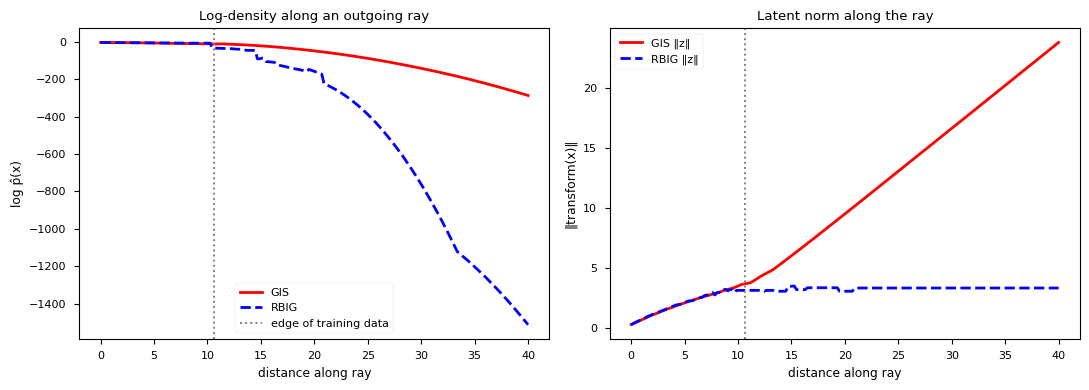

In [5]:
center = X_train.mean(axis=0)
direction = np.array([1.0, 1.0]) / np.sqrt(2.0)
ts = np.linspace(0.0, 40.0, 200)  # distance along the ray
probes = center[None, :] + ts[:, None] * direction[None, :]  # (200, 2)

# Distance at which the ray leaves the convex hull of the training data
# (approximated by the max projection of the training data on the ray).
t_max = np.max((X_train - center) @ direction)

ll_gis = gis.score_samples(probes)
ll_rbig = rbig.score_samples(probes)
z_gis = gis.transform(probes)
z_rbig = rbig.transform(probes)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(ts, ll_gis, "r-", lw=2, label="GIS")
ax.plot(ts, ll_rbig, "b--", lw=2, label="RBIG")
ax.axvline(t_max, color="gray", ls=":", label="edge of training data")
ax.set_xlabel("distance along ray")
ax.set_ylabel("log p̂(x)")
ax.set_title("Log-density along an outgoing ray")
ax.legend()

ax = axes[1]
ax.plot(ts, np.linalg.norm(z_gis, axis=1), "r-", lw=2, label="GIS ‖z‖")
ax.plot(ts, np.linalg.norm(z_rbig, axis=1), "b--", lw=2, label="RBIG ‖z‖")
ax.axvline(t_max, color="gray", ls=":")
ax.set_xlabel("distance along ray")
ax.set_ylabel("‖transform(x)‖")
ax.set_title("Latent norm along the ray")
ax.legend()
plt.tight_layout()
plt.show()

Past the edge of the training data the two models diverge qualitatively:

- **GIS** latents grow **linearly** with distance (the spline tails), so
  the log-density decreases **smoothly and monotonically** — roughly
  quadratically in the distance. Points further out always score lower.
- **RBIG** latents **saturate** once every marginal CDF clips. Right at
  the clip transition the log-determinant collapses (the clipped CDF has
  near-zero derivative), so the log-density **plunges** by orders of
  magnitude — and then goes **flat**: beyond saturation, a point just past
  the support and one absurdly far away receive *the same* score.

In [6]:
far_labels = ["inside", "near edge", "2× support", "4× support", "8× support"]
far_points = np.array([0.3, 0.9, 2.0, 4.0, 8.0])[:, None] * t_max * direction + center
print(f"{'probe':12s} {'GIS log p̂':>12s} {'RBIG log p̂':>12s}")
for label, lg, lr in zip(
    far_labels, gis.score_samples(far_points), rbig.score_samples(far_points)
):
    print(f"{label:12s} {lg:12.2f} {lr:12.2f}")
print("all GIS log-densities finite:", np.all(np.isfinite(gis.score_samples(far_points))))

probe          GIS log p̂  RBIG log p̂


inside              -5.00        -4.84
near edge           -9.67        -7.12
2× support         -57.50      -234.24
4× support        -332.62     -1511.98
8× support       -1575.38     -1511.98
all GIS log-densities finite: True


Note the last two RBIG rows: identical scores at 4× and 8× the support —
the model can no longer *rank* out-of-support points by how anomalous they
are, while GIS still can.

## Negative Side of the Boundary

The Gamma marginals are supported on the positive side; probing *negative*
coordinates tests extrapolation past a hard lower bound.

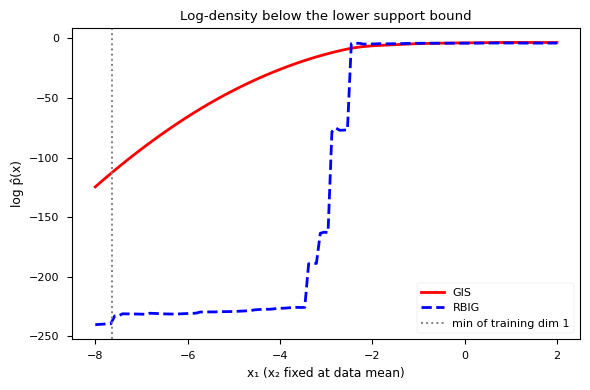

In [7]:
neg_probes = np.stack(
    [np.linspace(-8.0, 2.0, 120), np.full(120, float(center[1]))], axis=1
)
ll_gis_neg = gis.score_samples(neg_probes)
ll_rbig_neg = rbig.score_samples(neg_probes)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(neg_probes[:, 0], ll_gis_neg, "r-", lw=2, label="GIS")
ax.plot(neg_probes[:, 0], ll_rbig_neg, "b--", lw=2, label="RBIG")
ax.axvline(X_train[:, 0].min(), color="gray", ls=":", label="min of training dim 1")
ax.set_xlabel("x₁ (x₂ fixed at data mean)")
ax.set_ylabel("log p̂(x)")
ax.set_title("Log-density below the lower support bound")
ax.legend()
plt.tight_layout()
plt.show()

Same story below the support: GIS decays smoothly and keeps ranking points
by how far out they are; RBIG plunges at the clip transition and then
flattens once its CDFs saturate.

## Roundtrip Stability for Out-of-Support Points

Because the spline tails are linear (hence exactly invertible), even
out-of-support points survive a forward/inverse roundtrip.

In [8]:
X_ood = np.concatenate([probes, neg_probes], axis=0)
X_rec = gis.inverse_transform(gis.transform(X_ood))
print(f"GIS  max roundtrip error on OOD points: {np.max(np.abs(X_rec - X_ood)):.2e}")

GIS  max roundtrip error on OOD points: 1.78e-14


---
## Summary

| | Empirical CDF (RBIG marginals) | RQ spline (GIS/SIG) |
|---|---|---|
| CDF outside support | saturates at 0 / 1, must clip | linear tail extrapolation |
| Latent for OOD point | pinned at clipped probit value | grows linearly, stays distinct |
| log-density for OOD point | plunges at the clip, then constant — no ranking | decreases smoothly and monotonically |
| OOD roundtrip | lossy (many x → one z) | exact to numerical precision |

When your workflow involves scoring points that may fall outside the
training support — outlier detection, likelihood-ratio tests, evaluating
on shifted data — prefer the spline-based models, or see the
[boundary issues notebook](07_boundary_issues.ipynb) for RBIG-side
mitigations (KDE-smoothed CDFs, support extension).

## See Also

- [Boundary Issues in Marginal Uniformization](07_boundary_issues.ipynb)
- [Theory — RBIG vs SIG/GIS](../notes/sliced_iterative_gaussianization.md)
- [GIS Demo](14_sliced_gaussianization.ipynb)